In [7]:
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchinfo import summary
from helper import normalize, denormalize, train_model, get_normalized_data, evaluate_model, denormalize_std
from model_examples import TinyCNN
from models import CNN_Astronomy
from scipy.stats import norm
import torch.nn.functional as F

In [8]:
DATA_PATH = "data_galah4"

# hyperparameters
batch_size = 32
learning_rate = 0.001
num_epochs = 100
patience = 10
train_fraction = 0.7
val_fraction = 0.15
# choose if calculate uncertainty
calculate_uncertainty = True


# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

# convert to tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# split into training, validation, and test sets
sample_size = len(spectra_tensor)
train_size = int(train_fraction * sample_size)
val_size = int(val_fraction * sample_size)
test_size = sample_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(67))

# create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



# select my own model
# model_choice = 'CNN_Astronomy'
model_choice = 'TinyCNN'
if calculate_uncertainty and model_choice == 'CNN_Astronomy':
     model = CNN_Astronomy(2 * n_labels)  # Output size is doubled for mean and log variance
elif model_choice == 'CNN_Astronomy':
     model = CNN_Astronomy(n_labels)  # Output size is n_labels for mean only
elif model_choice == 'TinyCNN':
     model = TinyCNN(2 * n_labels) if calculate_uncertainty else TinyCNN(n_labels)
else:
     raise ValueError("Invalid model choice.")

# Print the model summary before moving it to the device
summary(model, input_size=(1, 1, spectra_length))

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Define loss function and optimizer
if calculate_uncertainty:
    criterion = nn.GaussianNLLLoss()
else:
    criterion = nn.MSELoss()

def nll_loss(predictions, batch_labels):
    mean = predictions[:, :n_labels]
    log_std = predictions[:, n_labels:]
    std = torch.exp(log_std)  
    return torch.mean((0.5 * ((batch_labels - mean) / std) ** 2) + log_std)

def loss_function(inputs, labels, model):
    predictions = model(inputs)
    
    loss = nll_loss(predictions, labels)
    return loss



# def loss_function(inputs, labels, model):
#     predictions = model(inputs)
#     mean = predictions[:, :n_labels]
#     log_std = predictions[:, n_labels:]

#     # Softplus safely enforces positive variance, 1e-6 prevents absolute zero
#     var = F.softplus(log_std) + 1e-6  
#     loss = criterion(mean, labels, var)
#     return loss






# call function
train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device)

# Final evaluation on the test dataset
model.load_state_dict(best_model)  # Load the best model
# save the best model to the "models" directory
if not os.path.exists('Deep-Learning/models'):
    os.makedirs('Deep-Learning/models')
torch.save(best_model, f'Deep-Learning/models/{model_choice}_uncertainty_best.pth')


Using device: cuda
Epoch [1/100], Step [190/195], Loss: -1.6517
Epoch [1/100], Train Loss: -1.1800, Val Loss: -1.5344, Time: 2.94 seconds
Epoch [2/100], Step [190/195], Loss: -1.6705
Epoch [2/100], Train Loss: -1.6435, Val Loss: -1.8501, Time: 2.88 seconds
Epoch [3/100], Step [190/195], Loss: -1.8038
Epoch [3/100], Train Loss: -1.7896, Val Loss: -1.9685, Time: 2.93 seconds
Epoch [4/100], Step [190/195], Loss: -1.8503
Epoch [4/100], Train Loss: -1.8523, Val Loss: -1.8405, Time: 2.92 seconds
Epoch [5/100], Step [190/195], Loss: -1.9771
Epoch [5/100], Train Loss: -1.8720, Val Loss: -1.8872, Time: 2.87 seconds
Epoch [6/100], Step [190/195], Loss: -1.9898
Epoch [6/100], Train Loss: -1.9314, Val Loss: -1.7935, Time: 2.84 seconds
Epoch [7/100], Step [190/195], Loss: -2.0482
Epoch [7/100], Train Loss: -1.9505, Val Loss: -2.1480, Time: 2.87 seconds
Epoch [8/100], Step [190/195], Loss: -1.8553
Epoch [8/100], Train Loss: -2.0171, Val Loss: -2.0584, Time: 2.88 seconds
Epoch [9/100], Step [190/195]

Evaluating model on the test dataset...
Final Test Loss: -2.5190


/tmp/ipykernel_17192/223287767.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'Deep-Learning/models/{model_choice}_uncertainty_best.pt

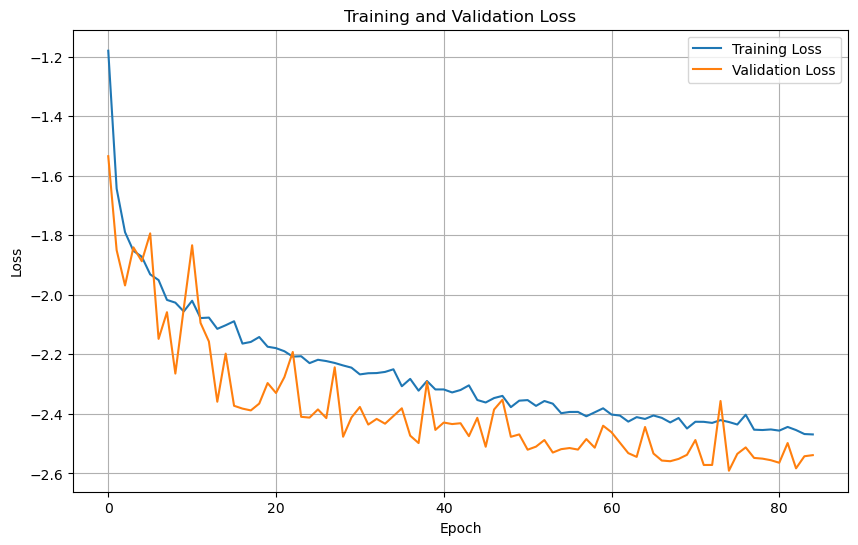

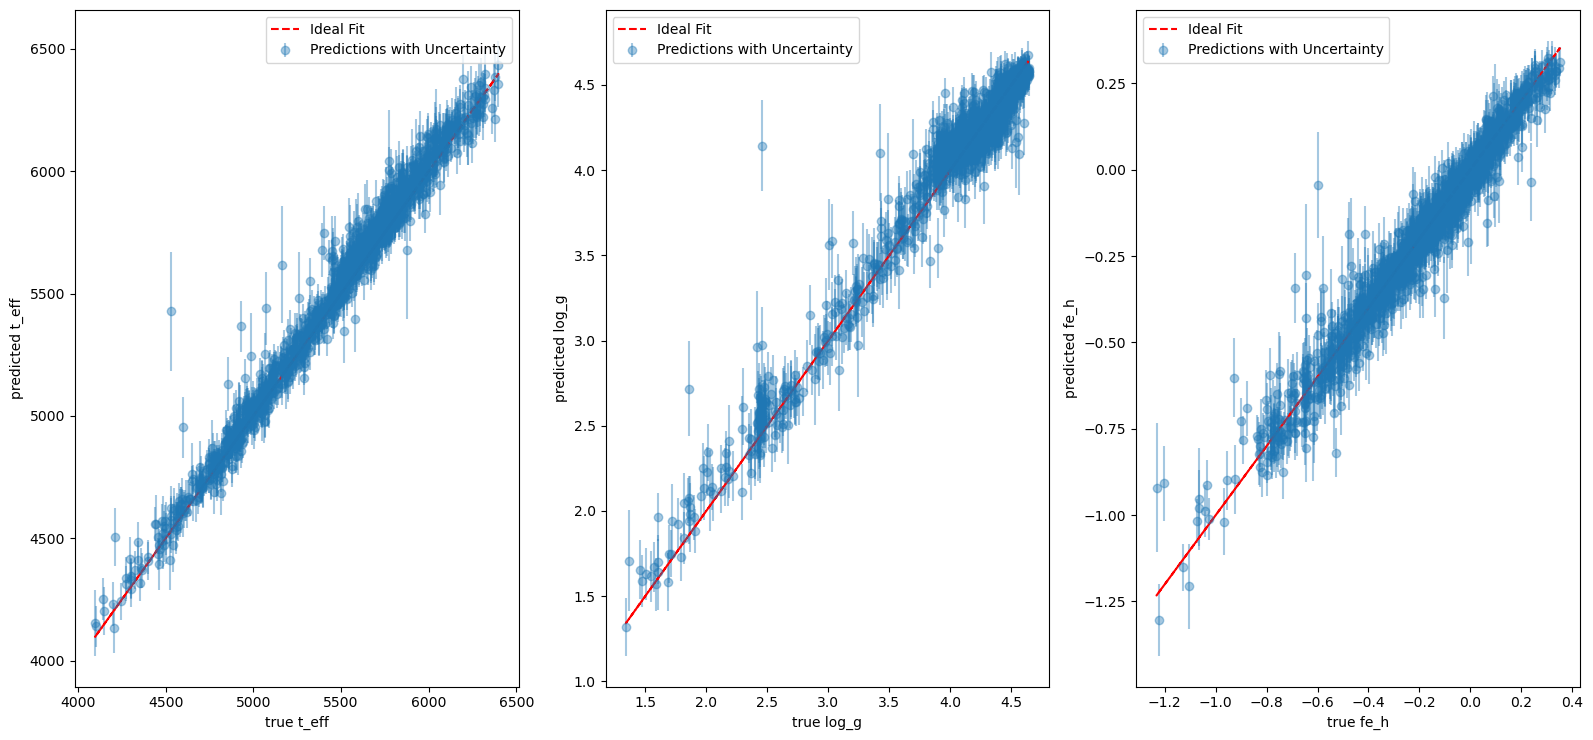

In [9]:
model.load_state_dict(torch.load(f'Deep-Learning/models/{model_choice}_uncertainty_best.pth'))  # Load the best model
model.to(device)

all_predictions, all_true_labels,_,_ = evaluate_model(model, test_loader, loss_function, device)
# denormalize prediction mean, standard deviation, and true labels
all_predictions[:, :n_labels] = denormalize(all_predictions[:, :n_labels], ranges[:n_labels])

normalized_log_std = all_predictions[:, n_labels:]
normalized_std = np.exp(normalized_log_std)  # Convert log standard deviation to standard deviation
denormalized_std = denormalize_std(normalized_std, ranges)
all_predictions[:, n_labels:] = denormalized_std  # Update the predictions with denormalized standard deviation

all_true_labels = denormalize(all_true_labels, ranges)  # Denormalize true labels





# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(f'plots/{model_choice}_training_validation_loss_un.png')

# plots with uncertainty
if calculate_uncertainty:
    plt.figure(figsize=(16,7.5))
    for j in range(n_labels):
        plt.subplot(1, n_labels, j+1)
        
        # Pull the already-calculated standard deviation from the array
        std_for_plot = all_predictions[:, n_labels+j]
        
        # Plot with 2*std for a ~95% confidence interval
        plt.errorbar(all_true_labels[:, j], all_predictions[:, j], 
                     yerr= std_for_plot, 
                     fmt='o', label='Predictions with Uncertainty', alpha=0.4)
                     
        plt.plot(all_true_labels[:, j], all_true_labels[:, j], 'r--', label='Ideal Fit')
        plt.xlabel("true " + labelNames[j])
        plt.ylabel("predicted " + labelNames[j])
        plt.legend()
        
    plt.tight_layout()
    plt.savefig(f'plots/{model_choice}_scatter_with_uncertainty.png')
    plt.show()
else:
    # Scatter plots for predictions without uncertainty
    plt.figure(figsize=(16,7.5))
    for j in range(n_labels):
        plt.subplot(1, n_labels, j+1)
        plt.scatter(all_true_labels[:, j], all_predictions[:, j], label='Predictions', alpha=0.5)
        plt.plot(all_true_labels[:, j], all_true_labels[:, j], 'r--', label='Ideal Fit')
        plt.xlabel("true "+labelNames[j])

Label: t_eff, Mean of errors: 35.6970, Std of errors: 64.7519
Label: log_g, Mean of errors: 0.0174, Std of errors: 0.1248
Label: fe_h, Mean of errors: -0.0052, Std of errors: 0.0604


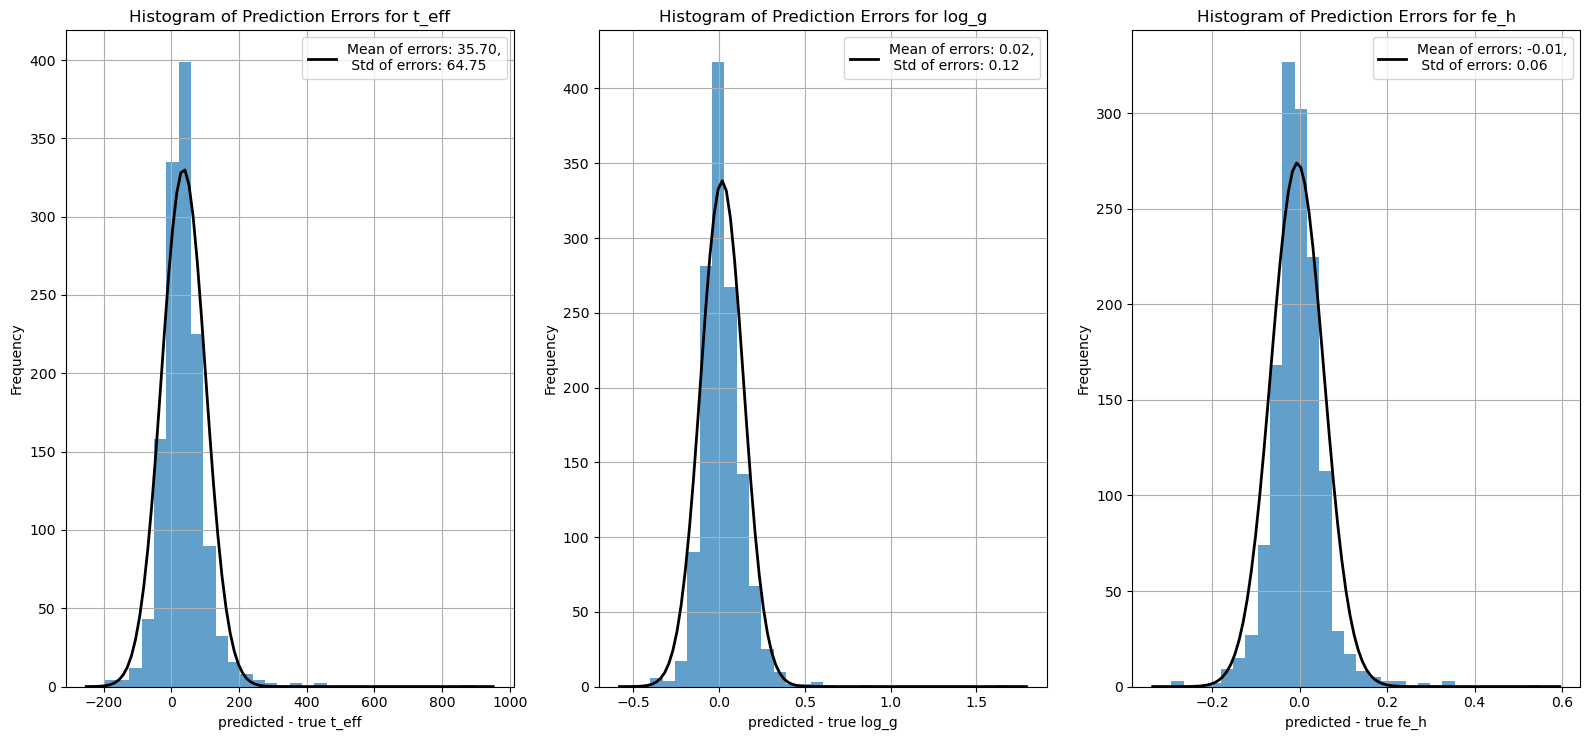

In [10]:
# plot histogram of predicted - true values for each label
plt.figure(figsize=(16,7.5))
for j in range(n_labels):
    plt.subplot(1, n_labels, j+1)
    plt.hist(all_predictions[:, j] - all_true_labels[:, j], bins=30, alpha=0.7)
    plt.xlabel("predicted - true " + labelNames[j])
    plt.ylabel("Frequency")
    plt.title("Histogram of Prediction Errors for " + labelNames[j])
    plt.grid()
    # fit a normal distribution to the histogram and plot it
    mu, std = norm.fit(all_predictions[:, j] - all_true_labels[:, j])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p * len(all_predictions[:, j]) * (xmax - xmin) / 30, 'k', linewidth=2, label=f'Mean of errors: {mu:.2f},\n Std of errors: {std:.2f}')
    plt.legend()
    print(f"Label: {labelNames[j]}, Mean of errors: {mu:.4f}, Std of errors: {std:.4f}")

plt.tight_layout()
# plt.savefig(f'plots/{model_choice}_prediction_error_histograms.png')
plt.show()

Label: t_eff, Mean of pulls: 0.4763, Std of pulls: 0.7272
Label: log_g, Mean of pulls: 0.1120, Std of pulls: 0.9061
Label: fe_h, Mean of pulls: -0.1077, Std of pulls: 0.8022


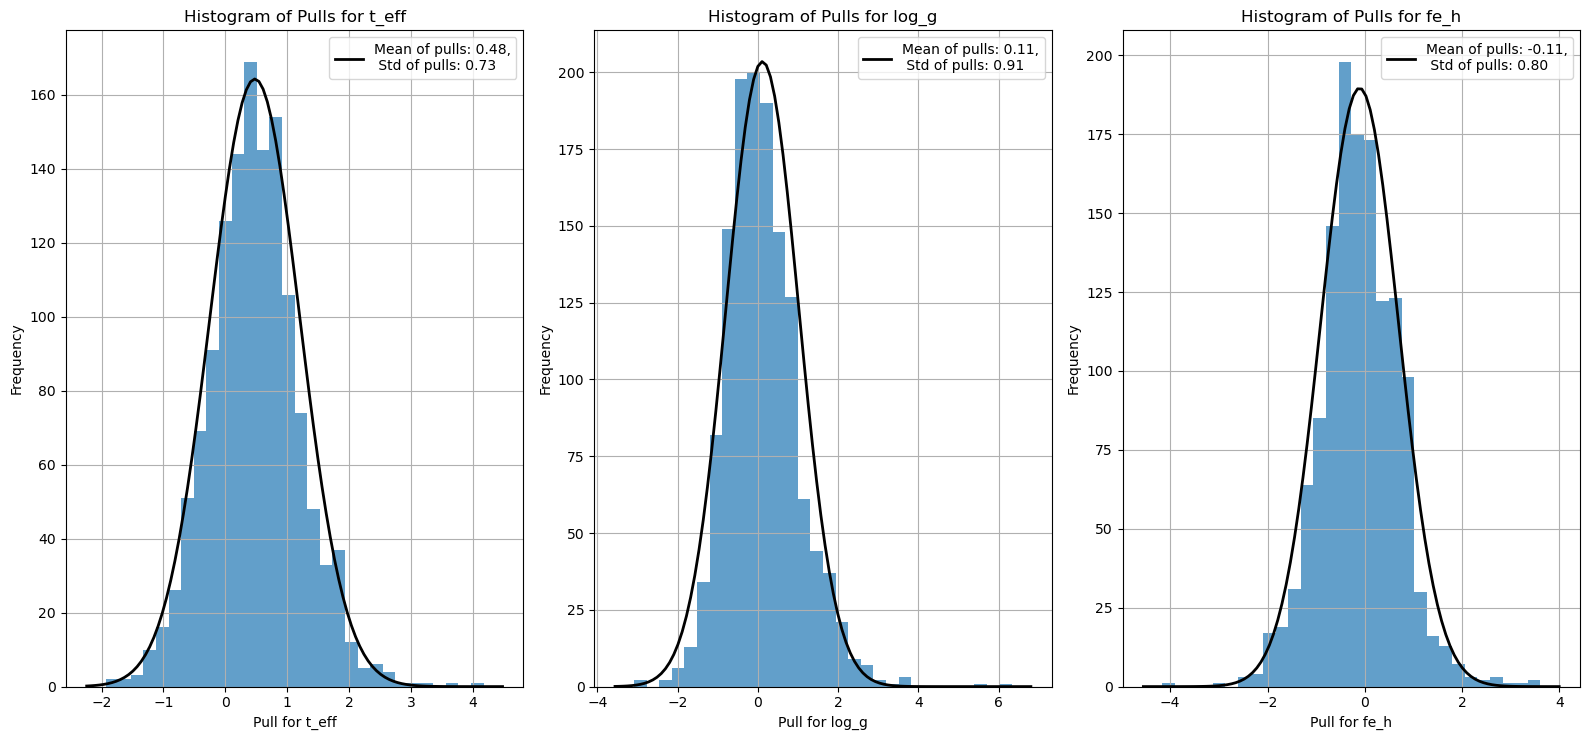

In [11]:
# calculate pull distribution for each label
plt.figure(figsize=(16,7.5))
for j in range(n_labels):
    plt.subplot(1, n_labels, j+1)
    pulls = (all_predictions[:, j] - all_true_labels[:, j]) / all_predictions[:, n_labels+j]
    plt.hist(pulls, bins=30, alpha=0.7)
    plt.xlabel("Pull for " + labelNames[j])
    plt.ylabel("Frequency")
    plt.title("Histogram of Pulls for " + labelNames[j])
    plt.grid()
    # fit a normal distribution to the histogram and plot it
    mu, std = norm.fit(pulls)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p * len(pulls) * (xmax - xmin) / 30, 'k', linewidth=2, label=f'Mean of pulls: {mu:.2f},\n Std of pulls: {std:.2f}')
    plt.legend()
    print(f"Label: {labelNames[j]}, Mean of pulls: {mu:.4f}, Std of pulls: {std:.4f}")

plt.tight_layout()
plt.savefig(f'plots/{model_choice}_pull_histograms_uncertainty.png')
plt.show()

In [ ]:
.png')

In [12]:
print("\n--- Uncertainty Evaluation ---")

for j in range(n_labels):
    print(f"\nEvaluating: {labelNames[j]}")
    
    y_true = all_true_labels[:, j]
    y_pred = all_predictions[:, j]
    sigma = all_predictions[:, n_labels + j]
    
    # 1. Z-scores
    z_scores = (y_true - y_pred) / sigma
    z_mean = np.mean(z_scores)
    z_std = np.std(z_scores)
    print(f"  Z-score Mean : {z_mean:.3f} (Ideal: 0.0)")
    print(f"  Z-score Std  : {z_std:.3f} (Ideal: 1.0)")
    
    # 2. Empirical Coverage
    coverage_1sigma = np.mean(np.abs(y_true - y_pred) <= 1.0 * sigma) * 100
    coverage_2sigma = np.mean(np.abs(y_true - y_pred) <= 2.0 * sigma) * 100
    print(f"  1-Sigma Coverage : {coverage_1sigma:.1f}% (Ideal: ~68.3%)")
    print(f"  2-Sigma Coverage : {coverage_2sigma:.1f}% (Ideal: ~95.4%)")
    
    # 3. RMSE vs RMV
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    rmv = np.sqrt(np.mean(sigma**2))
    print(f"  RMSE vs RMV  : {rmse:.3f} vs {rmv:.3f} (Ideal: roughly equal)")


--- Uncertainty Evaluation ---

Evaluating: t_eff
  Z-score Mean : -0.476 (Ideal: 0.0)
  Z-score Std  : 0.727 (Ideal: 1.0)
  1-Sigma Coverage : 77.7% (Ideal: ~68.3%)
  2-Sigma Coverage : 97.7% (Ideal: ~95.4%)
  RMSE vs RMV  : 73.940 vs 75.346 (Ideal: roughly equal)

Evaluating: log_g
  Z-score Mean : -0.112 (Ideal: 0.0)
  Z-score Std  : 0.906 (Ideal: 1.0)
  1-Sigma Coverage : 78.2% (Ideal: ~68.3%)
  2-Sigma Coverage : 96.6% (Ideal: ~95.4%)
  RMSE vs RMV  : 0.126 vs 0.125 (Ideal: roughly equal)

Evaluating: fe_h
  Z-score Mean : 0.108 (Ideal: 0.0)
  Z-score Std  : 0.802 (Ideal: 1.0)
  1-Sigma Coverage : 82.1% (Ideal: ~68.3%)
  2-Sigma Coverage : 97.9% (Ideal: ~95.4%)
  RMSE vs RMV  : 0.061 vs 0.067 (Ideal: roughly equal)
